In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



df = pd.read_csv('merged_dataset.csv', low_memory=False)
print(f'Shape: {df.shape}')
print(f"Missing % (top 20):")
print((df.isnull().mean() * 100).sort_values(ascending = False).round(1).head(20))
print(f"\nTarget variable:")


Shape: (32393, 66)
Missing % (top 20):
zolo_estimate        100.0
walk_score           100.0
lot_size              68.1
number_of_storeys     63.4
bedrooms              62.9
parking_spaces        62.9
bathrooms             62.8
sale_date             62.8
taxes                 62.8
source                62.8
listing_date          62.8
house_age             62.8
square_feet           62.7
latitude              62.7
city                  62.7
address               62.7
sold_price_y          62.7
listing_price         62.7
longitude             62.7
property_type         62.7
dtype: float64

Target variable:


In [59]:
print(df.shape)
print(df.columns.tolist())

(32393, 66)
['homeData_propertyId', 'homeData_listingId', 'homeData_url', 'homeData_mlsStatusId', 'homeData_listingMetadata_hasVirtualTour', 'homeData_propertyType', 'homeData_beds', 'homeData_baths', 'homeData_priceInfo_amount', 'homeData_priceInfo_displayLevel', 'homeData_priceInfo_priceType', 'homeData_priceInfo_homePrice_displayLevel', 'homeData_priceInfo_homePrice_int64Value', 'homeData_sqftInfo_displayLevel', 'homeData_photosInfo_photoRanges', 'homeData_photosInfo_primaryPhotoDisplayLevel', 'homeData_photosInfo_secondaryPhotoDisplayLevel', 'homeData_daysOnMarket_listingAddedDate', 'homeData_daysOnMarket_displayLevel', 'homeData_yearBuilt_displayLevel', 'homeData_lotSize_displayLevel', 'homeData_hoaDues_amount', 'homeData_hoaDues_displayLevel', 'homeData_sashes', 'homeData_directAccessInfo_timeZone_id', 'homeData_bathInfo_computedTotalBaths', 'homeData_addressInfo_centroid_centroid_latitude', 'homeData_addressInfo_centroid_centroid_longitude', 'homeData_addressInfo_centroid_displa

In [60]:
df['sold_price'] = df['sold_price_x'].combine_first(df['sold_price_y'])
df = df.drop(columns = ['sold_price_x', 'sold_price_y'])

df = df.rename(columns = {
    'square_feet': 'square_feet_num',
    'lot_size': 'lot_size_sqft'
})

df['listing_year'] = pd.to_datetime(df['listing_date']).dt.year
df['listing_month'] = pd.to_datetime(df['listing_date']).dt.month
df['bath_bed_ratio'] = df['bathrooms'] / df['bedrooms'].replace(0, np.nan)

print(f"Shape {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"sold_price stats:\n {df['sold_price'].describe().apply(lambda x: f"${x:,.0f}")}")
print((df.isnull().mean() * 100).sort_values(ascending = False).round(1).head(20))
print(f"\nTarget variable:")

Shape (32393, 68)
Columns: ['homeData_propertyId', 'homeData_listingId', 'homeData_url', 'homeData_mlsStatusId', 'homeData_listingMetadata_hasVirtualTour', 'homeData_propertyType', 'homeData_beds', 'homeData_baths', 'homeData_priceInfo_amount', 'homeData_priceInfo_displayLevel', 'homeData_priceInfo_priceType', 'homeData_priceInfo_homePrice_displayLevel', 'homeData_priceInfo_homePrice_int64Value', 'homeData_sqftInfo_displayLevel', 'homeData_photosInfo_photoRanges', 'homeData_photosInfo_primaryPhotoDisplayLevel', 'homeData_photosInfo_secondaryPhotoDisplayLevel', 'homeData_daysOnMarket_listingAddedDate', 'homeData_daysOnMarket_displayLevel', 'homeData_yearBuilt_displayLevel', 'homeData_lotSize_displayLevel', 'homeData_hoaDues_amount', 'homeData_hoaDues_displayLevel', 'homeData_sashes', 'homeData_directAccessInfo_timeZone_id', 'homeData_bathInfo_computedTotalBaths', 'homeData_addressInfo_centroid_centroid_latitude', 'homeData_addressInfo_centroid_centroid_longitude', 'homeData_addressInfo_

In [61]:
df['missing_count'] = df.isnull().sum(axis =1)
print(df['missing_count'].value_counts().sort_index())

missing_count
0         7
1         1
2      9374
3      2475
4       138
5        16
6         7
7         5
8         8
9        32
15       27
16        3
18        1
24    20072
25      158
26        2
27       65
28        2
Name: count, dtype: int64


In [62]:
sparse_rows = df[df['missing_count'] >= 24]
print(f"Sparse rows: {len(sparse_rows):,}")
print(f"\n Sample of sparse rows - homeData vs clean columns:")
print(sparse_rows[['homeData_beds', 'bedrooms',
                   'homeData_baths', 'bathrooms',
                   'homeData_addressInfo_city', 'city',
                   'homeData_priceInfo_amount', 'listing_price',
                   'sold_price',]].head(10))

Sparse rows: 20,299

 Sample of sparse rows - homeData vs clean columns:
    homeData_beds  bedrooms  homeData_baths  bathrooms  \
0             4.0       NaN             1.0        NaN   
1             4.0       NaN             1.0        NaN   
2             2.0       NaN             1.0        NaN   
3             6.0       NaN             4.0        NaN   
4             3.0       NaN             1.0        NaN   
5             3.0       NaN             2.0        NaN   
6             2.0       NaN             1.0        NaN   
8             2.0       NaN             1.0        NaN   
9             6.0       NaN             3.0        NaN   
10            4.0       NaN             2.0        NaN   

   homeData_addressInfo_city city  homeData_priceInfo_amount  listing_price  \
0          Nestleton Station  NaN                     730000            NaN   
1          Nestleton Station  NaN                     665000            NaN   
2                   Caesarea  NaN                  

In [63]:
df['bedrooms'] = df['bedrooms'].fillna(df['homeData_beds'])
df['bathrooms'] = df['bathrooms'].fillna(df['homeData_baths'])
df['city'] = df['city'].fillna(df['homeData_addressInfo_city'])
df['listing_price'] = df['listing_price'].fillna(df['homeData_priceInfo_amount'])
df['latitude'] = df['latitude'].fillna(df['homeData_addressInfo_centroid_centroid_latitude'])
df['longitude'] = df['longitude'].fillna(df['homeData_addressInfo_centroid_centroid_longitude'])

print("Missing % after recovery:")
kept_cols = ['sold_price', 'listing_price', 'bedrooms', 'bathrooms',
             'city', 'latitude', 'longitude', 'square_feet_num',
             'lot_size_sqft', 'taxes', 'median_income', 'population',
             'parking_spaces', 'property_type', 'house_age']
print((df[kept_cols].isnull().mean() * 100).sort_values(ascending = False).round(1))

Missing % after recovery:
lot_size_sqft      68.1
parking_spaces     62.9
house_age          62.8
taxes              62.8
population         62.7
square_feet_num    62.7
median_income      62.7
property_type      62.7
bedrooms            0.4
bathrooms           0.2
longitude           0.0
sold_price          0.0
latitude            0.0
city                0.0
listing_price       0.0
dtype: float64


In [64]:
sparse_rows = df[df['square_feet_num'].isna()]
print(f"Sparse rows: {len(sparse_rows):,}")
print(f"\n Sample checking homeData equivalents")
print(sparse_rows[['homeData_propertyType', 'property_type',
                   'homeData_lotSize_amount', 'lot_size_sqft',
                   'homeData_bathInfo_computedTotalBaths', 'bathrooms',
                   ]].head(10))


homedata_unused_col = [i for i in df.columns if i.startswith('homeData')
                       and i not in ['homeData_beds', 'homeData_baths',
                                     'homeData_addressInfo_city', 'homeData_priceInfo_amount', 
                                     'homeData_addressInfo_centroid_centroid_latitude',
                                     'homeData_addressInfo_centroid_centroid_longitude'
                                     ]]

for i in homedata_unused_col:
    print(f" {i}: {df[i].notna().sum():,} non-null")

Sparse rows: 20,299

 Sample checking homeData equivalents
    homeData_propertyType property_type  homeData_lotSize_amount  \
0                       6           NaN                  20800.0   
1                       6           NaN                  10400.0   
2                       6           NaN                      0.0   
3                       7           NaN                     77.0   
4                       6           NaN                  17500.0   
5                       6           NaN                  23958.0   
6                       6           NaN                   5422.0   
8                       6           NaN                  16719.0   
9                       6           NaN                      0.0   
10                      6           NaN                  16500.0   

   lot_size_sqft  homeData_bathInfo_computedTotalBaths  bathrooms  
0            NaN                                   1.0        1.0  
1            NaN                                   1.0  

In [65]:
crossover = df[df['property_type'].notna()][['homeData_propertyType', 'property_type' ]]
print(crossover.groupby(['homeData_propertyType', 'property_type']).size().reset_index(name = 'count').sort_values('count', ascending = False).head(20))
df['lot_size_sqft'] = df['lot_size_sqft'].fillna(df['homeData_lotSize_amount'])
print(f'\n lot_size_sqft missing after recovery: {df['lot_size_sqft'].isna().sum():,}')

    homeData_propertyType         property_type  count
13                      6              Detached   6306
2                       3       Condo Apartment   1733
25                     13     Att/Row/Townhouse   1507
19                      6         SEMI-DETACHED   1125
12                      6       Condo Townhouse   1023
16                      6                  Link    187
23                      8           Vacant Land     40
1                       3  Common Element Condo     33
3                       3        Detached Condo     23
8                       4                Duplex     23
4                       3                 House     20
18                      6     Rural Residential     12
20                      7                  Farm     12
14                      6                 House      9
5                       3       Leasehold Condo      9
7                       3   Semi-Detached Condo      8
11                      4               Triplex      5
17        

In [66]:
for col in ['square_feet_num', 'lot_size_sqft', 'taxes', 'median_income',
            'population', 'parking_spaces', 'number_of_storeys',
            'days_since_sold', 'listing_year', 'listing_month', 'bath_bed_ratio']:
    
    if col in df.columns:
        print(f'{col}: dtype = {df[col].dtype}, sample = {df[col].dropna().head(3).tolist()}')

square_feet_num: dtype = object, sample = ['700-1100 sqft', '700-1100 sqft', '700-1100 sqft']
lot_size_sqft: dtype = object, sample = [20800.0, 10400.0, 0.0]
taxes: dtype = float64, sample = [3534.0, 5040.0, 3600.0]
median_income: dtype = float64, sample = [87817.0, 87817.0, 87817.0]
population: dtype = float64, sample = [22000.0, 22000.0, 22000.0]
parking_spaces: dtype = float64, sample = [4.0, 4.0, 3.0]
number_of_storeys: dtype = float64, sample = [1.0, 1.0, 1.0]
days_since_sold: dtype = int64, sample = [220, 184, 213]
listing_year: dtype = float64, sample = [2025.0, 2025.0, 2026.0]
listing_month: dtype = float64, sample = [11.0, 11.0, 1.0]
bath_bed_ratio: dtype = float64, sample = [0.6666666666666666, 1.0, 0.3333333333333333]


In [67]:
mapping_type = (df[df['property_type'].notna()]
                .groupby('homeData_propertyType')['property_type']
                .agg(lambda x: x.mode()[0]).to_dict())
df['property_type'] = df['property_type'].fillna(df['homeData_propertyType'].map(mapping_type))

col_drop = [i for i in df.columns if i.startswith('homeData_')]
col_drop += ['source', 'mls_number', 'address', 'sold_date_dt',
             'listing_date', 'sale_date', 'walk_score', 'zolo_estimate', 'missing_count']

df =df.drop(columns = [ i for i in col_drop if i in df.columns])

df = df.dropna(subset = ['sold_price', 'listing_price', 'bedrooms',
                         'bathrooms', 'city', 'property_type'])


def parse_sqft(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    nums = [int(x) for x in str(val).replace(',', '').split() if x.isdigit()]
    if len(nums) ==2:
        return (nums[0] + nums[1]) / 2
    elif len(nums) ==1:
        return float(nums[0])
    return np.nan

df['square_feet_num'] = df['square_feet_num'].apply(parse_sqft)
df['lot_size_sqft'] = pd.to_numeric(df['lot_size_sqft'], errors = 'coerce')

for col in ['square_feet_num', 'lot_size_sqft', 'taxes', 'median_income',
            'population', 'parking_spaces', 'number_of_storeys',
            'days_since_sold', 'listing_year', 'listing_month', 'bath_bed_ratio']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

df['house_age'] = df['house_age'].fillna("Unknown")

Q1, Q3 = df['sold_price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[(df['sold_price'] >= Q1 -3*IQR) & (df['sold_price'] <= Q3 + 3*IQR)]

print(f'Final shape: {df.shape}')
print(f"\n Missing values remaining: {df.isnull().sum().sum()}")
print("\n Sold price stats:")
print(df['sold_price'].describe().apply(lambda x: f'${x:,.0f}'))
print(f'\nColumns remaining:')
print(df.columns.tolist())


Final shape: (31789, 20)

 Missing values remaining: 0

 Sold price stats:
count       $31,789
mean       $993,131
std        $404,464
min         $61,000
25%        $715,000
50%        $912,000
75%      $1,200,000
max      $2,715,000
Name: sold_price, dtype: object

Columns remaining:
['days_since_sold', 'city', 'listing_price', 'bedrooms', 'bathrooms', 'square_feet_num', 'number_of_storeys', 'latitude', 'longitude', 'property_type', 'house_age', 'lot_size_sqft', 'taxes', 'median_income', 'population', 'parking_spaces', 'sold_price', 'listing_year', 'listing_month', 'bath_bed_ratio']


In [68]:
df.to_csv("cleaned_dataset.csv", index = False)
print('Saved to cleaned_dataset.csv')

Saved to cleaned_dataset.csv


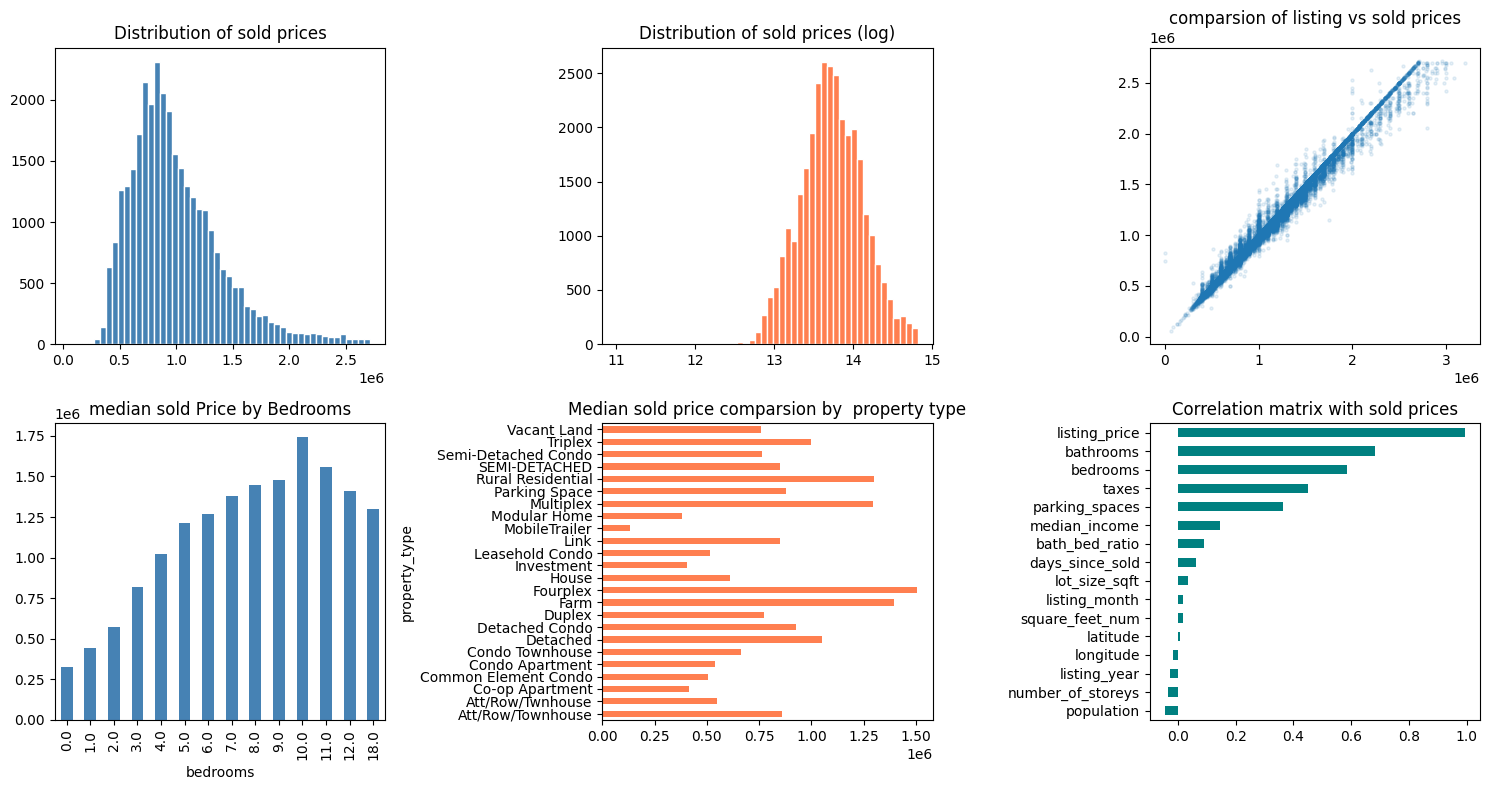

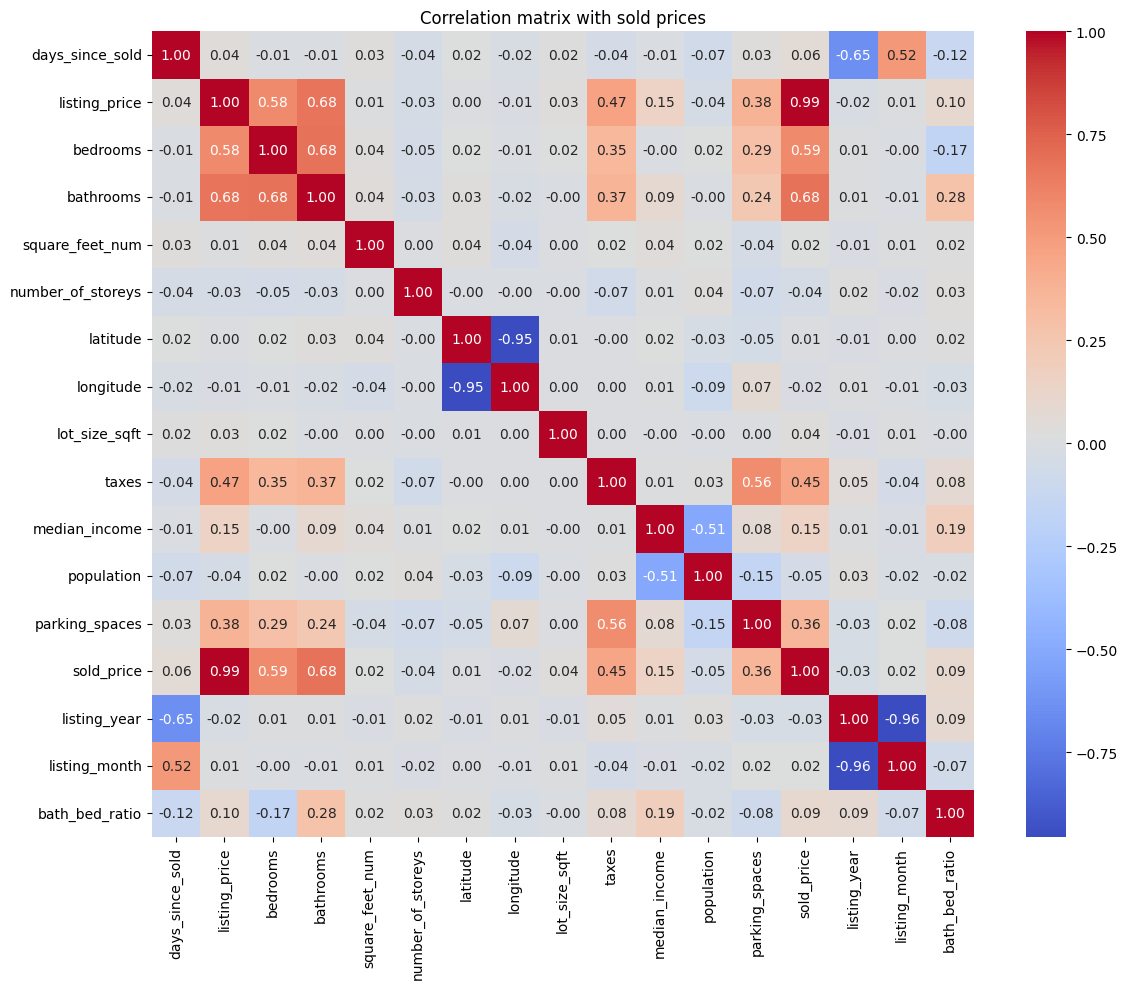


 Correlations with sold prices (top result)
listing_price        0.994451
bathrooms            0.682256
bedrooms             0.586647
taxes                0.449856
parking_spaces       0.363433
median_income        0.146441
bath_bed_ratio       0.091209
days_since_sold      0.063026
lot_size_sqft        0.035932
listing_month        0.015780
square_feet_num      0.015694
latitude             0.006388
longitude           -0.015976
listing_year        -0.028281
number_of_storeys   -0.036241
population          -0.045703


In [72]:
fig, axes = plt.subplots(2,3, figsize = (15, 8))

axes[0,0].hist(df['sold_price'], bins = 50, color = 'steelblue', edgecolor = 'white')
axes[0,0].set_title("Distribution of sold prices")

axes[0,1].hist(np.log1p(df['sold_price']), bins = 50, color = 'coral', edgecolor = 'white')
axes[0,1].set_title("Distribution of sold prices (log)")

axes[0,2].scatter(df["listing_price"], df['sold_price'], alpha = 0.1, s = 5)
axes[0,2].set_title("comparsion of listing vs sold prices")

df.groupby('bedrooms')['sold_price'].median().plot(kind = 'bar', ax = axes[1,0], color = 'steelblue')
axes[1,0].set_title('median sold Price by Bedrooms')

df.groupby('property_type')['sold_price'].median().plot(kind = 'barh', ax = axes[1,1], color = 'coral')
axes[1,1].set_title("Median sold price comparsion by  property type")

corr =df.select_dtypes(include = np.number).corr()["sold_price"].drop('sold_price').sort_values()
corr.plot(kind = 'barh', ax =axes[1,2], color = 'teal')
axes[1,2].set_title("Correlation matrix with sold prices")


plt.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize = (12,10))
num_cols = df.select_dtypes(include = np.number).columns
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot =True, fmt ='.2f', cmap= 'coolwarm')

ax.set_title('Correlation matrix with sold prices')
plt.tight_layout()
plt.show()

print('\n Correlations with sold prices (top result)')
print(corr.sort_values(ascending=False).to_string())

In [73]:
df.to_csv("cleaned_dataset.csv", index = False)
print(f'Saved {df.shape}')

Saved (31789, 20)


In [75]:
df['price_per_sqft'] = df['listing_price'] / df['lot_size_sqft'].replace(0, np.nan)
df['price_diff_pct'] = (df['sold_price'] - df['listing_price']) /df['listing_price'] * 100
df['sold_over_asking'] = (df['sold_price'] > df["listing_price"]).astype(int)
df['beds_plus_baths'] = df['bedrooms'] / df['bathrooms']
df['taxes_per_sqft'] = df['taxes'] / df['square_feet_num'].replace(0, np.nan)

ordering_age ={'New':0, '0-5 Years': 1, '6-10 Years': 2, '6 -15 Years': 2, 
               '11-15 Years': 3, '16-30 Years': 4, '31-50 Years': 5,
               '51-99 Years': 6, "100+ Years": 7, 'Unknown': -1}
df['encoded_house_age'] = df['house_age'].map(ordering_age)

print('New features added:')
print(df[['price_per_sqft','price_diff_pct','sold_over_asking',''
'beds_plus_baths','taxes_per_sqft','encoded_house_age' ]].describe())

New features added:
       price_per_sqft  price_diff_pct  sold_over_asking  beds_plus_baths  \
count    2.509000e+04    3.178900e+04      31789.000000         31778.00   
mean     5.829866e+03    4.931757e+03          0.070150              inf   
std      8.386619e+04    6.225047e+05          0.255404              NaN   
min      3.367003e-04   -4.284548e+01          0.000000             0.00   
25%      2.197031e+02   -1.578947e+00          0.000000             1.00   
50%      2.979798e+02    0.000000e+00          0.000000             1.25   
75%      4.017987e+02    0.000000e+00          0.000000             1.50   
max      2.650000e+06    8.199990e+07          1.000000              inf   

       taxes_per_sqft  encoded_house_age  
count    31789.000000       20272.000000  
mean         1.080479          -0.983425  
std          0.370496           0.127674  
min          0.000000          -1.000000  
25%          1.062400          -1.000000  
50%          1.062400          -1.000

In [76]:
print('house_age value counts:')
print(df['house_age'].value_counts().head(20))

print(f'\n Listing price <=0 {(df['listing_price'] <= 0).sum()}')
print(f'Listing price <=1000 {(df['listing_price'] < 1000).sum()}')

print(f'\n Bedrooms null: {df['bedrooms'].isna().sum()}')
print(f'Bedrooms null: {df['bedrooms'].isna().sum()}')
print(f'\n Bedrooms sample: {df['bedrooms'].unique()[:10]}')

house_age value counts:
house_age
Unknown       19936
No Data        7415
16-30          1075
31-50           902
0-5 years       683
6-15            602
51-99           542
New             336
6-10            137
11-15            98
100+ years       63
Name: count, dtype: int64

 Listing price <=0 0
Listing price <=1000 2

 Bedrooms null: 0
Bedrooms null: 0

 Bedrooms sample: [ 4.  2.  6.  3.  1.  5.  7.  8. 10.  0.]


In [79]:
df = df[df['listing_price'] >= 1000]

df['bedrooms'] = df['bedrooms'].replace(0,1)

new_age_order = {"New": 0, "0-5 years": 1,
                 '6-10': 2, "6-15":2,
                 "11-15": 3, '16-30': 4,
                 '31-50': 5, '51-99': 6,
                 '100+ years': 7,
                 'Unknown': -1,
                 'No Data': -1}

df['encoded_house_age'] = df['house_age'].map(new_age_order)

df['price_per_sqft'] = df['listing_price'] / df['lot_size_sqft'].replace(0, np.nan)
df['price_diff_pct'] = (df['sold_price'] - df['listing_price']) /df['listing_price'] * 100
df['beds_plus_baths'] = df['bedrooms'] + df['bathrooms']
df['taxes_per_sqft'] = df['taxes'] / df['square_feet_num'].replace(0, np.nan)
df['bath_bed_ratio'] = df['bathrooms'] / df['bedrooms']

print('New features added:')
print(df[['price_per_sqft','price_diff_pct','beds_plus_baths',
     'taxes_per_sqft','encoded_house_age' ]].describe())
print(f"\nencoded_house_age value counts:")
print(df['encoded_house_age'].value_counts())
print(f"\n Any nulls: {df.isnull().sum().sum()}")

New features added:
       price_per_sqft  price_diff_pct  beds_plus_baths  taxes_per_sqft  \
count    2.508800e+04    31787.000000     31787.000000    31787.000000   
mean     5.830331e+03       -0.760504         6.733932        1.080496   
std      8.386952e+04        3.958222         2.199133        0.370501   
min      5.199394e-02      -42.845479         1.000000        0.000000   
25%      2.197655e+02       -1.578947         5.000000        1.062400   
50%      2.979798e+02        0.000000         7.000000        1.062400   
75%      4.018159e+02        0.000000         8.000000        1.062400   
max      2.650000e+06       75.333918        26.000000       18.784286   

       encoded_house_age  
count       31787.000000  
mean           -0.389813  
std             1.676964  
min            -1.000000  
25%            -1.000000  
50%            -1.000000  
75%            -1.000000  
max             7.000000  

encoded_house_age value counts:
encoded_house_age
-1    27349
 4     

In [80]:
df['price_per_sqft'] = df['price_per_sqft'].fillna(df['price_per_sqft'].median())
df['taxes_per_sqft'] = df['taxes_per_sqft'].fillna(df['taxes_per_sqft'].median())

In [81]:
print(f"Nulls remaining: {df.isnull().sum().sum()}")
print(f"Null breakdown")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulls remaining: 0
Null breakdown
Series([], dtype: int64)


In [82]:
prop_type = df['property_type'].value_counts().nlargest(8).index
df['property_type'] = df['property_type'].where(df['property_type'].isin(prop_type), other = 'others')

df = pd.get_dummies(df, columns = ['property_type', 'city'], drop_first = True)

df = df.drop(columns = ['house_age'])

print(f"final shape: {df.shape}")
print(f" Nulls: {df.isnull().sum().sum()}")
print(f"\n Sample columns: {df.columns.tolist()[:10]}")

final shape: (31787, 150)
 Nulls: 0

 Sample columns: ['days_since_sold', 'listing_price', 'bedrooms', 'bathrooms', 'square_feet_num', 'number_of_storeys', 'latitude', 'longitude', 'lot_size_sqft', 'taxes']


In [83]:
df.to_csv("cleaned_dataset.csv", index = False)
print(f'Saved {df.shape}')

Saved (31787, 150)


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from  sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

In [89]:
X = df.drop(columns = ['sold_price'])
Y = df['sold_price']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(x_scaled,Y, test_size = 0.2, random_state=42)

ols = LinearRegression()
ols.fit(x_train, y_train)
pred = ols.predict(x_test)

mape = mean_absolute_percentage_error(y_test, pred) * 100
r2 = r2_score(y_test, pred)

devination_10 = (np.abs(pred - y_test) / y_test <= 0.10).mean() * 100
devination_15 = (np.abs(pred - y_test) / y_test <= 0.15).mean() * 100

print("--Base OLD Model---")
print(f"Mape:  {mape:.2f}%")
print(f"R^2     {r2:.4f}")
print(f"Within 10:  {devination_10:.1f}%")
print(f"Within 15:  {devination_15:.1f}%")

cv_scores = cross_val_score(LinearRegression(), x_scaled, Y, cv = 5, scoring = 'r2')
print(f"\n CV r^2 scores:  {cv_scores.round(4)}")
print(f"\n mean CV r^2 scores:  {cv_scores.mean():.4f}")
print(f"\n std CV r^2 scores:  {cv_scores.std():.4f}")


--Base OLD Model---
Mape:  0.82%
R^2     0.9982
Within 10:  99.3%
Within 15:  99.6%

 CV r^2 scores:  [0.9979 0.9983 0.9983 0.9975 0.9973]

 mean CV r^2 scores:  0.9979

 std CV r^2 scores:  0.0004


In [91]:
correlation = pd.Series([abs(df[col].corr(df['sold_price'])) for col in X.columns],
                        index = X.columns).sort_values(ascending = False)

print("top 15 correlations with sold_prices:")
print(correlation.head(60))

top 15 correlations with sold_prices:
listing_price                         0.994564
beds_plus_baths                       0.688680
bathrooms                             0.682262
bedrooms                              0.586909
property_type_Detached                0.457090
taxes                                 0.449841
property_type_Condo Apartment         0.424756
taxes_per_sqft                        0.373663
parking_spaces                        0.363431
bath_bed_ratio                        0.150627
median_income                         0.146420
property_type_Condo Townhouse         0.134571
city_York                             0.127013
city_Durham                           0.122840
city_Oshawa                           0.113873
city_Richmond Hill                    0.106169
city_Woodbridge                       0.096202
city_Markham                          0.088336
price_per_sqft                        0.086714
city_Maple                            0.084465
city_Peel             

In [93]:
#testing data leakage
ols = LinearRegression()
ols.fit(x_train, y_train)

train_pred =ols.predict(x_train)
test_pred = ols.predict(x_test)

train_mape = mean_absolute_percentage_error(y_train, train_pred) * 100
test_mape = mean_absolute_percentage_error(y_test, test_pred) * 100

devination_10 = (np.abs(pred - y_test) / y_test <= 0.10).mean() * 100
devination_15 = (np.abs(pred - y_test) / y_test <= 0.15).mean() * 100

print("test vs training gap")
print(f"Train Mape:  {train_mape:.2f}%")
print(f"Test Mape:  {test_mape:.2f}%")

print(f"Train R^2     {r2_score(y_train, train_pred):.4f}")
print(f"Test R^2     {r2_score(y_test, test_pred):.4f}")
print(f"Within 10:  {abs(train_mape - test_mape):.2f}%")





test vs training gap
Train Mape:  0.78%
Test Mape:  0.82%
Train R^2     0.9982
Test R^2     0.9982
Within 10:  0.04%


In [98]:
from sklearn.linear_model import RidgeCV, LassoCV

ridge = RidgeCV(alphas = [0.01, 0.1, 1, 10, 100, 1000], cv =5)
ridge.fit(x_train, y_train)
ridge_pred = ridge.predict(x_test)

lasso = LassoCV(cv = 5, random_state = 42, max_iter = 1000)
lasso.fit(x_train, y_train)
lasso_pred = lasso.predict(x_test)

for title, pred in [('Ridge', ridge_pred), ('lasso', lasso_pred)]:
    inner_mape = mean_absolute_percentage_error(y_test, pred) * 100
    inner_r2 = r2_score(y_test, pred)
    devination_10 = (np.abs(pred - y_test) / y_test <= 0.10).mean() * 100
    devination_15 = (np.abs(pred - y_test) / y_test <= 0.15).mean() * 100
    print("--ridge vs lasso---")
    print(f"Mape:  {inner_mape:.2f}%")
    print(f"R^2     {inner_r2:.4f}")
    print(f"Within 10:  {devination_10:.1f}%")
    print(f"Within 15:  {devination_15:.1f}%")

print(f"\ridge best alpha:{ridge.alpha_} ")
print(f"\lasso best alpha:{lasso.alpha_:.6f} ")
print(f"Lasso features kept: {(lasso.coef_ !=0)} / {len(lasso.coef_)}")

--ridge vs lasso---
Mape:  0.83%
R^2     0.9982
Within 10:  99.3%
Within 15:  99.6%
--ridge vs lasso---
Mape:  0.79%
R^2     0.9982
Within 10:  99.3%
Within 15:  99.6%
idge best alpha:10.0 
\lasso best alpha:401.210225 
Lasso features kept: [ True  True False  True False False  True  True False  True False False
  True False False False  True  True  True  True  True False False  True
  True  True False False False False False False False False False False
 False False False False False False False  True False False False  True
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
  True False False False False False False False False False False False
  True  True False False False False False False False False False False
 False False False False  True False  True False False False False False
 False  True False False Fals

In [101]:
names_of_features = X.columns.tolist()
lasso_feat = [names_of_features[s] for s, words in enumerate(lasso.coef_ !=0) if words]

print(f" Lasso kept {len(lasso_feat)} features")
for f in lasso_feat:
    print(f" {f}")

 Lasso kept 27 features
 days_since_sold
 listing_price
 bathrooms
 latitude
 longitude
 taxes
 parking_spaces
 price_per_sqft
 price_diff_pct
 sold_over_asking
 beds_plus_baths
 taxes_per_sqft
 property_type_Condo Apartment
 property_type_Condo Townhouse
 property_type_Detached
 city_Brampton
 city_Burlington
 city_King City
 city_Maple
 city_Markham
 city_Oshawa
 city_Peel
 city_Richmond Hill
 city_Thornhill
 city_Whitchurch-stouffville
 city_Woodbridge
 city_York


In [104]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_x = df.drop(columns = ['sold_price', 'price_diff_pct', 'sold_over_asking'])
vif_x = vif_x.select_dtypes(include=[np.number])
vif_x = vif_x.replace([np.inf, -np.inf], np.nan).dropna()

data_vif = pd.DataFrame()
data_vif['feature'] = vif_x.columns
data_vif['VIF'] = [variance_inflation_factor(vif_x.values, t)
                   for t in range(vif_x.shape[1])]

data_vif = data_vif.sort_values("VIF", ascending = False)
print("VIF Scores:")
print(data_vif.head(60).to_string())

VIF Scores:
              feature           VIF
3           bathrooms           inf
2            bedrooms           inf
17    beds_plus_baths           inf
7           longitude  2.018485e+04
6            latitude  2.010282e+04
13       listing_year  6.332143e+03
4     square_feet_num  4.655751e+03
10      median_income  3.121996e+02
9               taxes  1.288694e+02
18     taxes_per_sqft  1.038893e+02
15     bath_bed_ratio  1.027887e+02
1       listing_price  1.593202e+01
14      listing_month  1.281667e+01
12     parking_spaces  1.131771e+01
11         population  8.659369e+00
0     days_since_sold  6.814354e+00
19  encoded_house_age  1.245703e+00
5   number_of_storeys  1.040571e+00
16     price_per_sqft  1.017913e+00
8       lot_size_sqft  1.007523e+00


In [113]:
vif_drop = {'beds_plus_baths', 'bath_bed_ratio', 'taxes_per_sqft',
            'latitude', 'longitude', 'listing_year',
             'square_feet_num', "median_income", 'taxes' }
clean_x = vif_x.drop(columns = [i for i in vif_drop if i in vif_x.columns])

data_vif_two = pd.DataFrame()
data_vif_two['feature'] = clean_x.columns
data_vif_two['VIF'] = [variance_inflation_factor(clean_x.values, t)
                   for t in range(clean_x.shape[1])]

data_vif_two = data_vif_two.sort_values("VIF", ascending = False)
print(f"Features remaining: {clean_x.shape[1]}")
print("VIF Scores:")
print(data_vif_two.head(20).to_string())

Features remaining: 11
VIF Scores:
              feature        VIF
3           bathrooms  19.441598
2            bedrooms  18.635181
1       listing_price  14.601894
8       listing_month  10.520884
7      parking_spaces   7.538290
0     days_since_sold   6.637075
6          population   4.303140
10  encoded_house_age   1.217703
4   number_of_storeys   1.031813
9      price_per_sqft   1.014635
5       lot_size_sqft   1.006371


In [114]:
clean_x = clean_x.drop(columns = ['bedrooms'])

data_vif_three = pd.DataFrame()
data_vif_three['feature'] = clean_x.columns
data_vif_three['VIF'] = [variance_inflation_factor(clean_x.values, t)
                   for t in range(clean_x.shape[1])]

data_vif_three = data_vif_three.sort_values("VIF", ascending = False)
print(f"Features remaining: {clean_x.shape[1]}")
print("VIF Scores:")
print(data_vif_three.head(20).to_string())

Features remaining: 10
VIF Scores:
             feature        VIF
1      listing_price  14.120255
2          bathrooms  13.880669
7      listing_month  10.411689
6     parking_spaces   7.184564
0    days_since_sold   6.636748
5         population   4.175044
9  encoded_house_age   1.217504
3  number_of_storeys   1.031763
8     price_per_sqft   1.014570
4      lot_size_sqft   1.006000


In [115]:
clean_x = clean_x.drop(columns = ['listing_month'])

data_vif_four = pd.DataFrame()
data_vif_four['feature'] = clean_x.columns
data_vif_four['VIF'] = [variance_inflation_factor(clean_x.values, t)
                   for t in range(clean_x.shape[1])]

data_vif_four = data_vif_four.sort_values("VIF", ascending = False)
print(f"Features remaining: {clean_x.shape[1]}")
print("VIF Scores:")
print(data_vif_four.head(20).to_string())

Features remaining: 9
VIF Scores:
             feature        VIF
1      listing_price  14.120241
2          bathrooms  13.552687
6     parking_spaces   6.864103
0    days_since_sold   4.177926
5         population   3.834953
8  encoded_house_age   1.212956
3  number_of_storeys   1.030232
7     price_per_sqft   1.014566
4      lot_size_sqft   1.005999


In [118]:
X_version_three = clean_x.copy()
Y = df['sold_price']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X_version_three)

x_train, x_test, y_train, y_test = train_test_split(x_scaled,Y, test_size = 0.2, random_state=42)

def evalute(name, model):
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    mape = mean_absolute_percentage_error(y_test, pred) * 100
    r2 = r2_score(y_test, pred)

    devination_10 = (np.abs(pred - y_test) / y_test <= 0.10).mean() * 100
    devination_15 = (np.abs(pred - y_test) / y_test <= 0.15).mean() * 100
    print(f"\--{name}---")
    print(f"Mape:  {mape:.2f}%")
    print(f"R^2     {r2:.4f}")
    print(f"Within 10:  {devination_10:.1f}%")
    print(f"Within 15:  {devination_15:.1f}%")

ols = evalute('OLS', LinearRegression())
ridge = evalute("Ridge", RidgeCV(alphas = [0.01, 0.1, 1, 10, 100, 1000], cv =5))
lasso = evalute("Lasso", LassoCV(cv =5, random_state = 42, max_iter = 1000))

\--OLS---
Mape:  2.14%
R^2     0.9908
Within 10:  96.8%
Within 15:  98.9%
\--Ridge---
Mape:  2.14%
R^2     0.9908
Within 10:  96.8%
Within 15:  98.9%
\--Lasso---
Mape:  2.13%
R^2     0.9909
Within 10:  96.8%
Within 15:  98.9%


In [125]:
from sklearn.feature_selection import SequentialFeatureSelector

# SFS

sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select='auto',
    direction='forward',
    scoring='r2',
    cv=5
)

# BES

bes = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select='auto',
    direction='backward',
    scoring='r2',
    cv=5
)

sfs.fit(x_scaled, Y)
features_forwards = X_version_three.columns[sfs.get_support()].tolist()

bes.fit(x_scaled, Y)
features_backward = X_version_three.columns[bes.get_support()].tolist()

print(f"sfs selcted {len(features_forwards)} features")
for i in features_forwards:
    print(f" {i}")

print(f"bes selcted {len(features_backward)} features")
for i in features_backward:
    print(f" {i}")

print(f"Feature in both: {set(features_forwards) & set(features_backward)}")
print(f"Feature in SFS: {set(features_forwards) - set(features_backward)}")
print(f"Feature in BFE: {set(features_backward) - set(features_forwards)}")

for title, cover in [('OLS + SFS', sfs.get_support()),
                     ('OLS + BES', bes.get_support())]:
    
    sel_x = x_scaled[:, cover]
    tr_x, te_x, tr_y, te_y =  train_test_split(sel_x,Y, test_size = 0.2, random_state=42)
    model = LinearRegression()
    model.fit(tr_x, tr_y)
    pred = model.predict(te_x)
    mape = mean_absolute_percentage_error(te_y, pred) * 100
    r2 = r2_score(te_y, pred)
    devination_10 = (np.abs(pred - te_y) / te_y <= 0.10).mean() * 100
    devination_15 = (np.abs(pred - te_y) / te_y <= 0.15).mean() * 100
    print(f"\--{title}---")
    print(f"Mape:  {mape:.2f}%")
    print(f"R^2     {r2:.4f}")
    print(f"Within 10:  {devination_10:.1f}%")
    print(f"Within 15:  {devination_15:.1f}%")

sfs selcted 4 features
 days_since_sold
 listing_price
 bathrooms
 parking_spaces
bes selcted 5 features
 days_since_sold
 listing_price
 bathrooms
 parking_spaces
 encoded_house_age
Feature in both: {'days_since_sold', 'bathrooms', 'parking_spaces', 'listing_price'}
Feature in SFS: set()
Feature in BFE: {'encoded_house_age'}
\--OLS + SFS---
Mape:  2.17%
R^2     0.9908
Within 10:  96.9%
Within 15:  98.9%
\--OLS + BES---
Mape:  2.13%
R^2     0.9908
Within 10:  96.8%
Within 15:  98.9%


In [128]:
final_set  = ['days_since_sold', "listing_price", 'bathrooms', 'parking_spaces', 'encoded_house_age']

final_model_x = df[final_set]
final_scaler = StandardScaler()
final_x_scaled = final_scaler.fit_transform(final_model_x)

model_final = LinearRegression()
model_final.fit(final_x_scaled, Y)

for stuff, coef in zip(final_set, model_final.coef_):
    print(f" {stuff}: {coef:,.2f}")
print(f" Intercept:{model_final.intercept_:,.2f}")

 days_since_sold: 9,285.52
 listing_price: 399,421.33
 bathrooms: 7,773.18
 parking_spaces: -7,273.53
 encoded_house_age: -3,422.16
 Intercept:993,143.94
